<a href="https://colab.research.google.com/github/Hirakhan15/PCOs/blob/main/VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

ROOT_DIR = '/content/drive/MyDrive/PCOS'
number_of_images = {}

for dir in os.listdir(ROOT_DIR):
   number_of_images[dir] = len(os.listdir(os.path.join(ROOT_DIR,dir)))
   print("",dir,"" ,number_of_images[dir])

 noninfected  5000
 infected  5000


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = []
for category in ['infected', 'noninfected']:
    folder_path = os.path.join(ROOT_DIR, category)
    for img in os.listdir(folder_path):
        data.append({'filepath': os.path.join(folder_path, img), 'label': category})

df = pd.DataFrame(data)

# Splitting 70/15/15
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Define Augmentation for VGG16
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # VGG16 specific normalization
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Assuming you already have train_df and val_df from the previous step
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='binary'
)

val_gen = test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='binary'
)

Found 7000 validated image filenames belonging to 2 classes.
Found 1500 validated image filenames belonging to 2 classes.


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model

# 1. Load VGG16 base
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base layers
vgg_base.trainable = False

# 3. Add a classification head
x = vgg_base.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model_vgg = Model(inputs=vgg_base.input, outputs=predictions)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Training execution
history_vgg = model_vgg.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint('pcos_vgg16_best.h5', save_best_only=True)
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8525 - loss: 1.4754 - precision: 0.8507 - recall: 0.8543

219/219 ━━━━━━━━━━━━━━━━━━━━ 1565s 7s/step - accuracy: 0.8527 - loss: 1.4723 - precision: 0.8510 - recall: 0.8545 - val_accuracy: 0.9500 - val_loss: 0.2275 - val_precision: 0.9245 - val_recall: 0.9800
Epoch 2/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.9364 - loss: 0.2473 - precision: 0.9369 - recall: 0.9350

219/219 ━━━━━━━━━━━━━━━━━━━━ 131s 595ms/step - accuracy: 0.9364 - loss: 0.2471 - precision: 0.9369 - recall: 0.9350 - val_accuracy: 0.9313 - val_loss: 0.1922 - val_precision: 0.8893 - val_recall: 0.9853
Epoch 3/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.9510 - loss: 0.1445 - precision: 0.9499 - recall: 0.9525

219/219 ━━━━━━━━━━━━━━━━━━━━ 131s 600ms/step - accuracy: 0.9510 - loss: 0.1445 - precision: 0.9499 - recall: 0.9525 - val_accuracy: 0.9647 - val_loss: 0.1387 - val_precision: 0.9395 - val_recall: 0.9933
Epoch 4/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.9527 - loss: 0.1250 - precision: 0.9530 - recall: 0.9511

219/219 ━━━━━━━━━━━━━━━━━━━━ 132s 600ms/step - accuracy: 0.9527 - loss: 0.1250 - precision: 0.9530 - recall: 0.9511 - val_accuracy: 0.9560 - val_loss: 0.1249 - val_precision: 0.9201 - val_recall: 0.9987
Epoch 5/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 133s 608ms/step - accuracy: 0.9635 - loss: 0.0987 - precision: 0.9675 - recall: 0.9595 - val_accuracy: 0.9573 - val_loss: 0.1339 - val_precision: 0.9214 - val_recall: 1.0000
Epoch 6/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.9595 - loss: 0.1104 - precision: 0.9576 - recall: 0.9613

219/219 ━━━━━━━━━━━━━━━━━━━━ 132s 604ms/step - accuracy: 0.9595 - loss: 0.1104 - precision: 0.9576 - recall: 0.9613 - val_accuracy: 0.9653 - val_loss: 0.1181 - val_precision: 0.9352 - val_recall: 1.0000
Epoch 7/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 132s 601ms/step - accuracy: 0.9653 - loss: 0.1002 - precision: 0.9669 - recall: 0.9630 - val_accuracy: 0.9307 - val_loss: 0.1564 - val_precision: 0.8782 - val_recall: 1.0000
Epoch 8/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 132s 600ms/step - accuracy: 0.9671 - loss: 0.0971 - precision: 0.9657 - recall: 0.9694 - val_accuracy: 0.9533 - val_loss: 0.1353 - val_precision: 0.9146 - val_recall: 1.0000
Epoch 9/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 132s 603ms/step - accuracy: 0.9726 - loss: 0.0808 - precision: 0.9715 - recall: 0.9735 - val_accuracy: 0.9587 - val_loss: 0.1617 - val_precision: 0.9236 - val_recall: 1.0000
Epoch 10/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 131s 596ms/step - accuracy: 0.9723 - loss: 0.0795 - precision: 0.9697 - recall: 0.9746 - val_accuracy: 0.9193 - va

In [12]:
test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

loss, accuracy, precision, recall = model_vgg.evaluate(test_gen)
print(f"Final Test Accuracy: {accuracy*100:.2f}%")
print(f"Final Test Precision: {precision*100:.2f}%")
print(f"Final Test Recall: {recall*100:.2f}%")

Found 1500 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.9635 - loss: 0.1097 - precision: 0.9296 - recall: 1.0000
Final Test Accuracy: 96.47%
Final Test Precision: 93.40%
Final Test Recall: 100.00%


47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 211ms/step


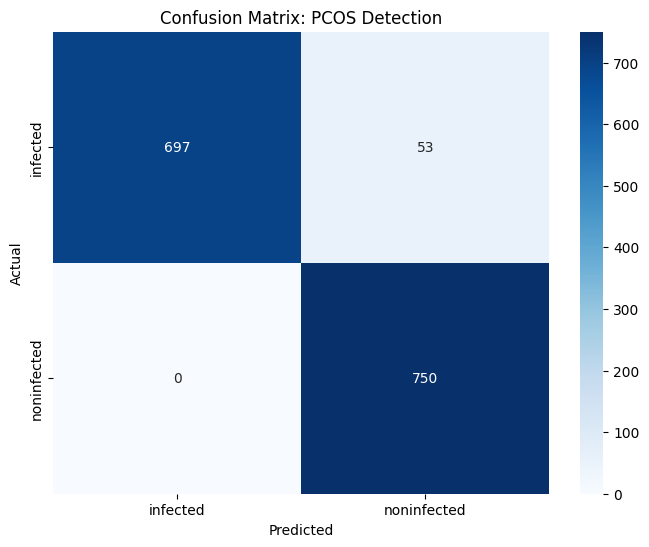


Classification Report:
              precision    recall  f1-score   support

    infected       1.00      0.93      0.96       750
 noninfected       0.93      1.00      0.97       750

    accuracy                           0.96      1500
   macro avg       0.97      0.96      0.96      1500
weighted avg       0.97      0.96      0.96      1500



In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions from the test set
# Important: shuffle=False in test_gen ensures labels match predictions
test_gen.reset()
predictions = model_vgg.predict(test_gen)
pred_labels = (predictions > 0.5).astype(int) # Convert probabilities to 0 or 1

# 2. Get true labels
true_labels = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# 3. Create Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: PCOS Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 4. Detailed Classification Report
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=class_names))

In [15]:
# Assuming 'cm' is your confusion matrix from the previous step
# In a binary classification (0=Healthy, 1=Infected):
# cm[0,0] = TN, cm[0,1] = FP
# cm[1,0] = FN, cm[1,1] = TP

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (Healthy correctly identified): {tn}")
print(f"False Positives (Healthy misidentified as PCOS): {fp}")
print(f"False Negatives (PCOS missed by model): {fn}")
print(f"True Positives (PCOS correctly identified): {tp}")

True Negatives (Healthy correctly identified): 697
False Positives (Healthy misidentified as PCOS): 53
False Negatives (PCOS missed by model): 0
True Positives (PCOS correctly identified): 750
